In [1]:
from google.colab import files
import pandas as pd
import io

# Upload your CSV (e.g., coursera_data.csv)
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Loaded {filename} with {df.shape[0]} rows.")
df.head()

Saving coursea_data.csv to coursea_data.csv
Loaded coursea_data.csv with 891 rows.


,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


In [2]:
# We focus on Course Name, Rating, and Enrollment Count
# Note: Adjust column names based on your specific CSV
cols_to_keep = ['course_title', 'course_rating', 'course_students_enrolled']
df_hr = df[cols_to_keep].copy()

# Convert enrollment strings (like '10k') to actual numbers if necessary
def convert_enrollment(val):
    if isinstance(val, str):
        val = val.lower().replace('k', '000').replace('m', '000000').replace('.', '')
        return int(''.join(filter(str.isdigit, val)))
    return val

df_hr['enrollment_count'] = df_hr['course_students_enrolled'].apply(convert_enrollment)
df_hr.head()

,course_title,course_rating,course_students_enrolled,enrollment_count
0,(ISC)² Systems Security Certified Practitioner...,4.7,5.3k,53000
1,A Crash Course in Causality: Inferring Causal...,4.7,17k,17000
2,A Crash Course in Data Science,4.5,130k,130000
3,A Law Student's Toolkit,4.7,91k,91000
4,A Life of Happiness and Fulfillment,4.8,320k,320000


In [3]:
# C is the mean rating across the whole catalog
C = df_hr['course_rating'].mean()

# m is the minimum enrollments required to be listed (e.g., 75th percentile)
m = df_hr['enrollment_count'].quantile(0.75)

def weighted_rating(x, m=m, C=C):
    v = x['enrollment_count']
    R = x['course_rating']
    # Calculation based on IMDB Formula
    return (v/(v+m) * R) + (m/(m+v) * C)

# Apply the score
df_hr['score'] = df_hr.apply(weighted_rating, axis=1)
print(f"Global Mean Rating: {C:.2f}")
print(f"Minimum Enrollments Required: {m}")

Global Mean Rating: 4.68
Minimum Enrollments Required: 99500.0


In [4]:
# Sort by score in descending order
popular_recommendations = df_hr.sort_values('score', ascending=False)

print("--- TOP 10 RECOMMENDED COURSES FOR EMPLOYEES ---")
popular_recommendations[['course_title', 'course_rating', 'enrollment_count', 'score']].head(10)

--- TOP 10 RECOMMENDED COURSES FOR EMPLOYEES ---


,course_title,course_rating,enrollment_count,score
564,Machine Learning,4.9,32000000,4.899310
815,The Science of Well-Being,4.9,25000000,4.899117
626,Neural Networks and Deep Learning,4.9,630000,4.869629
684,Python Data Structures,4.9,420000,4.857352
322,First Step Korean,4.9,400000,4.855644
427,Improving Deep Neural Networks: Hyperparameter...,4.9,270000,4.840038
512,Introduction to Psychology,4.9,270000,4.840038
291,Excel Skills for Business,4.9,240000,4.834740
162,Convolutional Neural Networks,4.9,240000,4.834740
124,COVID-19 Contact Tracing,4.9,220000,4.830655


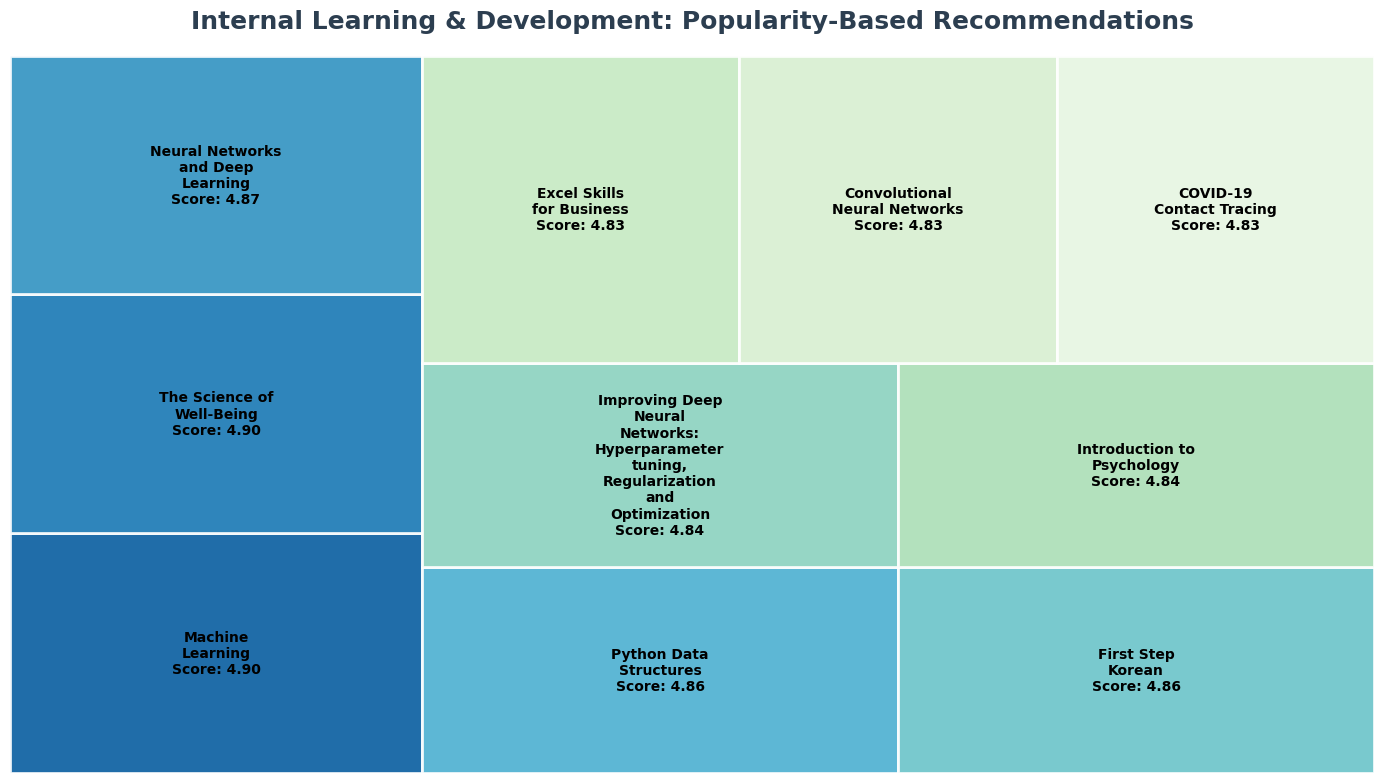

In [14]:
!pip install squarify # Install the missing library
import matplotlib.pyplot as plt
import squarify
import seaborn as sns
import textwrap

# 1. Prepare and Sort Data
# We take the top 10 and ensure they are sorted for the visual layout
data = popular_recommendations.head(10).sort_values('score', ascending=False)

# 2. Create Wrapped Labels
# This prevents long text from running out of the boxes
labels = []
for row in data.itertuples():
    wrapped_title = textwrap.fill(row.course_title, width=15) # Breaks long titles into new lines
    labels.append(f"{wrapped_title}\nScore: {row.score:.2f}")

# 3. Set Plot Style
plt.figure(figsize=(14, 8))
# 'GnBu_r' gives a professional, cool-toned HR dashboard look
colors = sns.color_palette("GnBu_r", len(data))

# 4. Create the TreeMap
squarify.plot(
    sizes=data['score'],
    label=labels,
    alpha=0.9,
    color=colors,
    ec="white",
    linewidth=2,
    text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'black'}
)

# 5. Final Formatting
plt.title('Internal Learning & Development: Popularity-Based Recommendations',
          fontsize=18, pad=20, fontweight='bold', color='#2c3e50')
plt.axis('off') # Hides the X and Y numbers for a cleaner look

plt.tight_layout()
plt.show()